In [1]:
"""
Created on Mar 15 2021

@author: rodrigo pena
"""

import numpy as np
import matplotlib.pyplot as plt
#plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "DejaVu Sans"
import pandas as pd
import time
from scipy import signal
from scipy.ndimage import gaussian_filter
import seaborn as sns
import random
import pylab
pylab.rcParams['savefig.dpi'] = 120
#matplotlib inline

In [2]:
""" Parameters simulation """
dt = 0.1
tf = 2000
N = round(tf/dt)

In [3]:
"""stim functions"""

Ipoisson = lambda r: 1*(np.random.rand()<r*10**-3*dt)
Izap = lambda i, Fzap, A: A*np.sin(2*np.pi*Fzap*10**-3*i*dt + 3*np.pi/2)

def rect(T):
    """create a centered rectangular pulse of width $T"""
    return lambda t: (-T/2 <= t) & (t < T/2)

def pulse_train(t, at, shape):
    """create a train of pulses over $t at times $at and shape $shape"""
    return np.sum(shape(t - at[:,np.newaxis]), axis=0)

In [4]:
class PYR:
    """The PYR model"""
    nid=0 #default neuron id
    sendspk=0
    
    Cm=1
    gL=0.25
    g1=0.25
    tau1=100     
    
    vth=4
    vr=-1
    
    gsyn=1
    tausyn=5
    Esyn=5
    countdelay=0
    
    gext = 0.3 ### 0.3 is default
    tauext=5
    Eext=5
 
    spktimes = []
    
    def __init__(self,nid=1,gL=0.25,g1=0.25,tau1=100,Esyn=5,gsyn=1.5,tausyn=5):
        self.nid = nid
        self.v = 0
        self.w = 0
        self.s = 0
        self.sext=0
        self.gL = gL
        self.g1 = g1
        self.tau1 = tau1
        self.Esyn=Esyn
        self.gsyn=gsyn
        self.tausyn=tausyn
        self.spktimes = []

    def _UpdateKs(self,v,w,s,sext,stim):
        Iampa = self.gsyn*s * (v-self.Esyn) 
        Iext = self.gext*sext * (v-self.Eext) 
        Itotal = stim - self.gL*v - self.g1*w - Iampa - Iext
        kv = Itotal / (self.Cm)
        kw = (v-w) / self.tau1
        ks = (-s/self.tausyn)
        ksext = -sext/self.tauext
        return kv, kw, ks, ksext

    def _Updatev(self,stim,dt,time):
        if(self.countdelay>0):
            self.countdelay-=dt
        if(self.countdelay<0):
            self.countdelay=0
            self.s += 1
        k1v, k1w, k1s, k1sext = self._UpdateKs(self.v,self.w,self.s,self.sext,stim)
        a_v= self.v + k1v*dt/2
        a_w= self.w + k1w*dt/2
        a_s= self.s + k1s*dt/2
        a_sext= self.sext + k1sext*dt/2
        k2v, k2w, k2s, k2sext = self._UpdateKs(a_v,a_w,a_s,a_sext,stim)
        a_v= self.v + k2v*dt/2
        a_w= self.w + k2w*dt/2
        a_s= self.s + k2s*dt/2
        a_sext= self.sext + k2sext*dt/2
        k3v, k3w, k3s, k3sext = self._UpdateKs(a_v,a_w,a_s,a_sext,stim)
        a_v= self.v + k3v*dt
        a_w= self.w + k3w*dt
        a_s= self.s + k3s*dt
        a_sext= self.sext + k3sext*dt
        k4v, k4w, k4s, k4sext = self._UpdateKs(a_v,a_w,a_s,a_sext,stim)
        self.v += dt*(k1v+2*k2v+2*k3v+k4v)/6 #0.3*np.random.rand()*np.sqrt(dt) + 
        self.w += dt*(k1w+2*k2w+2*k3w+k4w)/6
        self.s += dt*(k1s+2*k2s+2*k3s+k4s)/6
        self.sext += dt*(k1sext+2*k2sext+2*k3sext+k4sext)/6
        self.sendspk=0
        if(self.v>self.vth):
            self.v=self.vr
            self.spktimes.append(time)
            self.sendspk=1
            
    def add_pre_spike(self,delay):
        self.countdelay = delay 
        self.sendspk=0
        
    def delay_count(self,delay):
        self.countdelay = delay 
        
    def add_external(self):
        self.sext += 1
        
    def eval(self,stim,dt,time):  
        self._Updatev(stim,dt,time)

### single net

simulation time
4.214807987213135


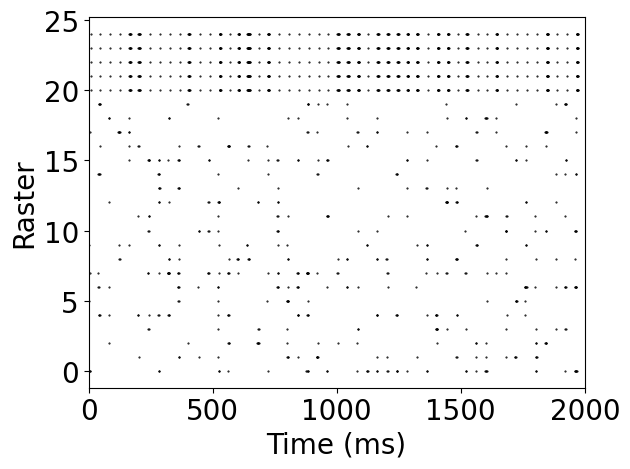

13.475


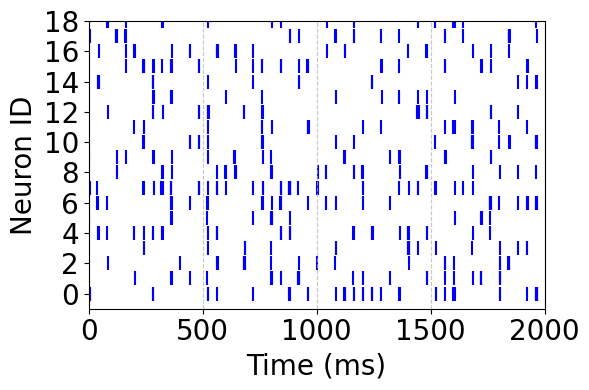

In [17]:
"""network
"""
"""network: evaluate sync item
"""
neuron_list = []
syn_list = []
stim = []
Nneuron = 25
Nex = 20
F=50
r=1000

sizePulse=10
i=np.arange(0,round(tf/dt))-1
intervals=np.arange(0,tf/dt,1000/(F*dt))
sig = pulse_train(
    t=i,              # time domain
    at=intervals,  # times of pulses
    shape=rect(sizePulse/dt)  # shape of pulse
)
sig = r*sig

v = np.empty((Nneuron,N))
delay=1.5

for i in np.arange(0,Nneuron):
    if(i<Nex):
        neuron_list.append(PYR(i,Esyn=-5,tausyn=6,gsyn=4)) #EX cells, receives only from in
        syn_list.append(np.arange(Nex,Nneuron))
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10
    else:
        neuron_list.append(PYR(i,gL=0.5,g1=0.0105,gsyn=3)) #IN cells, receives only from ex
        syn_list.append(np.arange(0,Nex))
        neuron_list[-1].v = 0
        
#         if(n<Nex and Ipoisson(100)):
#             neuron_list[n].add_external()        
         
start = time.time()    
for i in np.arange(0,round(tf/dt))-1:
    for n in np.arange(0,Nneuron):
        if(n<Nex and Ipoisson(sig[i])): #Ipoisson(600)): #sync vs async input ):Ipoisson(sig[i])
            neuron_list[n].add_external()
        neuron_list[n].eval(0,dt,i*dt)  
        if(neuron_list[n].sendspk==1 and len(syn_list[n])>0): #checking if active synapse
            [ neuron_list[x].add_pre_spike(delay) for x in syn_list[n] ]
        v[n,i] = neuron_list[n].v
           

end = time.time() 
print('simulation time')
print(end - start)

"""raster plot and other statistics"""

df = pd.DataFrame({'nid' : [], 'spktime' : []})
for n in np.arange(0,Nneuron):
    spks = neuron_list[n].spktimes
    df2 = pd.DataFrame({'nid' : n*np.ones(len(spks)), 'spktime' : spks})
    df = pd.concat([df, df2])

t = np.arange(0,tf,dt)       

#plt.figure(figsize=(8,10))
ax=plt.subplot(111)
plt.plot(df['spktime'],df['nid'],'.',c='k',ms=1)
# plt.xlim([1,400])
plt.ylabel('Raster')
plt.xlabel('Time (ms)')
plt.xlim([0,2000])
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)

plt.tight_layout()
plt.savefig('F50_new_new.png')
plt.show()

rate = len(df[df['nid']<Nex])/(tf*Nex*10**-3) 
print(rate)

# Plot Raster for Population 1
plt.figure(figsize=(6, 4))
ax=plt.subplot(111)
plt.scatter(df['spktime'],df['nid'], marker='|', color='blue', s=100)
# plt.title('Raster Plot - Excitatory Population 1', fontsize=16)
plt.xlabel('Time (ms)', fontsize=20)
plt.ylabel('Neuron ID', fontsize=20)
plt.xlim([0, tf])
plt.ylim([-1, Nex-2])
plt.yticks(range(0, Nex, max(1, Nex // 10)))
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.tight_layout()
plt.savefig('Raster_Plot_EI.pdf')
plt.savefig('Raster_Plot_EI.png')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


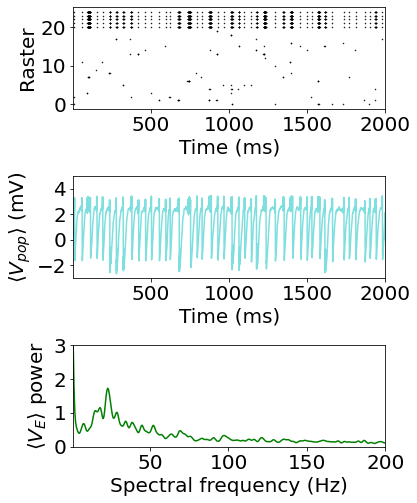

In [134]:
t = np.arange(0,tf,dt)       
# plt.subplot(411)
# [x,y] = np.histogram(df[df['nid']<Nex]['spktime'],bins=1000) #only over PC
# plt.plot(y[1:],gaussian_filter(x,sigma=0.4))

cm = 1/2.54  # centimeters in inches
# plt.subplots(figsize=(15*cm, 5*cm))
# plt.text(0.5, 0.5, '15cm x 5cm', **text_kwargs)

f1 = plt.figure(figsize=(15*cm,18*cm))

ax=plt.subplot(311)
plt.plot(df['spktime'],df['nid'],'.',c='k',ms=1)
plt.xlim([1,2000])
plt.ylabel('Raster')
plt.xlabel('Time (ms)')
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)

ax=plt.subplot(312)
plt.plot(t,np.average(v,axis=0),c='c',alpha=0.5)
plt.ylabel(r'$\langle V_{pop} \rangle$ (mV)')
plt.xlabel('Time (ms)')
plt.xlim([1,2000])
plt.ylim([-3,5])
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)

ax=plt.subplot(313)
ffv = np.fft.fft(np.average(v,axis=0))
sv = np.abs(ffv)/tf
deltaf = 1000/tf;
f= np.arange(0,len(ffv)*deltaf,deltaf)
plt.plot(f,gaussian_filter(sv,sigma=2), color='green',alpha=1)
plt.ylabel(r'$\langle V_{E} \rangle$ power')
plt.xlabel('Spectral frequency (Hz)')
plt.xlim([1,200])
plt.ylim([0,3])
plt.locator_params(axis='x', nbins=5)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.tight_layout()
plt.savefig('test_wI.png')
plt.savefig('test_wI.eps')
plt.show()

In [172]:
isis=np.array([])
for i in range(len(df)):
    ids = df[df['nid']==i]
    newisi=np.diff(ids['spktime']).flatten()
    isis = np.concatenate((isis,newisi))
    
    
rates_e = []
rates_i = []
for i in range(Nex):
    ids = df[df['nid']==i]
    rates_e.append(len(ids)/(tf*Nex*10**-3))
for i in range(Nex,Nneuron):
    ids = df[df['nid']==i]
    rates_i.append(len(ids)/(tf*Nex*10**-3))
    
    

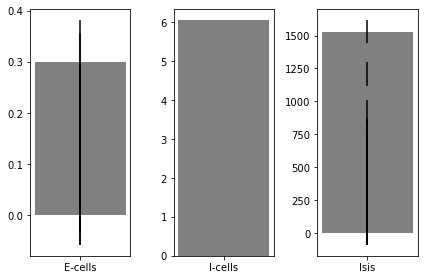

In [177]:
plt.subplot(131)
plt.bar( 'E-cells', rates_e, color = 'gray', yerr=np.std(rates_e) )
plt.subplot(132)
plt.bar( 'I-cells', rates_i, color = 'gray', yerr=np.std(rates_i) )
plt.subplot(133)
plt.bar( 'Isis', isis, color = 'gray', yerr=np.std(isis) )
plt.tight_layout()

In [149]:
rates_e

[0.25,
 0.325,
 0.125,
 0.1,
 0.15,
 0.15,
 0.225,
 0.2,
 0.125,
 0.025,
 0.025,
 0.1,
 0.025,
 0.275,
 0.15,
 0.175,
 0.075,
 0.125,
 0.075,
 0.05]

Text(0.5, 1.0, 'CV=4.344012052041311')

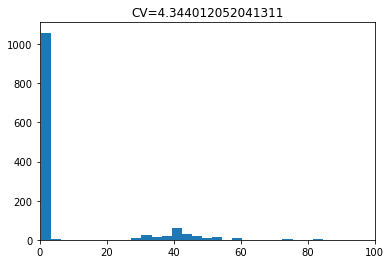

In [136]:
plt.hist(isis,400)
plt.xlim([0,100])
plt.title('CV='+str(np.std(isis)/np.mean(isis)))

In [111]:
range(Nex,Nneuron)

range(20, 25)

In [92]:
ids['spktime']

0     551.6
1    1483.9
2    1585.4
3    1587.4
4    1903.6
Name: spktime, dtype: float64

In [93]:
np.diff(ids['spktime']).flatten()

array([932.3, 101.5,   2. , 316.2])

In [90]:
newisi

array([932.3, 101.5,   2. , 316.2])

In [ ]:
###other characteristics

t = np.arange(0,tf,dt)       
# plt.subplot(411)
# [x,y] = np.histogram(df[df['nid']<Nex]['spktime'],bins=1000) #only over PC
# plt.plot(y[1:],gaussian_filter(x,sigma=0.4))

cm = 1/2.54  # centimeters in inches
# plt.subplots(figsize=(15*cm, 5*cm))
# plt.text(0.5, 0.5, '15cm x 5cm', **text_kwargs)

f1 = plt.figure(figsize=(15*cm,18*cm))

ax=plt.subplot(311)
plt.plot(df['spktime'],df['nid'],'.',c='k',ms=1)
plt.xlim([1,2000])
plt.ylabel('Raster')
plt.xlabel('Time (ms)')
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)

ax=plt.subplot(312)
plt.plot(t,np.average(v,axis=0),c='r',alpha=0.5)
plt.ylabel(r'$\langle V_{pop} \rangle$ (mV)')
plt.xlabel('Time (ms)')
plt.xlim([1,2000])
plt.ylim([-3,5])
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)

ax=plt.subplot(313)
ffv = np.fft.fft(np.average(v,axis=0))
sv = np.abs(ffv)/tf
deltaf = 1000/tf;
f= np.arange(0,len(ffv)*deltaf,deltaf)
plt.plot(f,gaussian_filter(sv,sigma=2), color='green',alpha=1)
plt.ylabel(r'$\langle V_{E} \rangle$ power')
plt.xlabel('Spectral frequency (Hz)')
plt.xlim([1,200])
plt.ylim([0,3])
plt.locator_params(axis='x', nbins=8)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.tight_layout()
plt.savefig('test_wI.png')
plt.savefig('test_wI.eps')
plt.show()

### Simulation sync vs async

In [16]:
def rate_async_sync(F1=40):
    neuron_list = []
    syn_list = []
    Nneuron = 25
    Nex = 20
    v = np.empty((Nneuron+Nex,N))
    delay=1.5

    r=1000
    sizePulse=10

    i=np.arange(0,round(tf/dt))-1
    intervals=np.arange(0,tf/dt,1000/(F1*dt))
    sig = pulse_train(
        t=i,              # time domain
        at=intervals,  # times of pulses
        shape=rect(sizePulse/dt)  # shape of pulse
    )
    sig = r*sig


    for i in np.arange(0,Nneuron):
        if(i<Nex):
            neuron_list.append(PYR(i,Esyn=-5,tausyn=6,gsyn=4)) #EX cells, receives only from in
            syn_list.append(np.arange(Nex,Nneuron))
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10
        else:
            neuron_list.append(PYR(i,gL=0.5,g1=0.0105,gsyn=3)) #IN cells, receives only from ex
            syn_list.append(np.concatenate((np.arange(0,Nex),np.arange(Nneuron,Nneuron+Nex))))
            neuron_list[-1].v = 0   

    #second item
    for i in np.arange(0,Nex):
            neuron_list.append(PYR(i,Esyn=-5,tausyn=6,gsyn=4)) #EX cells, receives only from in
            syn_list.append(np.arange(Nex,Nneuron))
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10

#     start = time.time()    
    for i in np.arange(0,round(tf/dt))-1:
        for n in np.arange(0,Nneuron+Nex):
            if(n<Nex and Ipoisson(sig[i])):
                neuron_list[n].add_external()
            if(n>=Nneuron and Ipoisson(600)): #second item
                neuron_list[n].add_external()
            if(neuron_list[n].sendspk==1 and len(syn_list[n])>0): #checking if active synapse
                [ neuron_list[x].add_pre_spike(delay) for x in syn_list[n] ]
            neuron_list[n].eval(0,dt,i*dt)     
            v[n,i] = neuron_list[n].v

#     end = time.time() 
#     print('simulation time')
#     print(end - start)    

    """raster plot and other statistics"""

    df = pd.DataFrame({'nid' : [], 'spktime' : []})
    for n in np.arange(0,Nneuron+Nex):
        spks = neuron_list[n].spktimes
        df2 = pd.DataFrame({'nid' : n*np.ones(len(spks)), 'spktime' : spks})
        df = pd.concat([df, df2])

    rate_F1 = len(df[df['nid']<Nex])/(tf*Nex*10**-3)  
    rate_F2 = len(df[df['nid']>=Nneuron])/(tf*Nex*10**-3) 
    
    ffv = np.fft.fft(np.average(v,axis=0))
    sv = np.abs(ffv)/tf
    deltaf = 1000/tf;
    f= np.arange(0,len(ffv)*deltaf,deltaf)
    sv = gaussian_filter(sv,sigma=1)
    pid = np.argmax(sv[1:50])
    
    ffvF1 = np.fft.fft(np.average(v[:Nex],axis=0))
    sv = np.abs(ffvF1)/tf
    sv = gaussian_filter(sv,sigma=1)
    pidF1 = np.argmax(sv[1:50])
    
    ffvF2 = np.fft.fft(np.average(v[Nneuron:],axis=0))
    sv = np.abs(ffvF2)/tf
    sv = gaussian_filter(sv,sigma=1)
    pidF2 = np.argmax(sv[1:50])
    
    return rate_F1, rate_F2, f[pid], f[pidF1], f[pidF2] 
    
rate_F1 = []
rate_F2 = []
pop_F = []
pop_F1 = []
pop_F2 = []
f = np.arange(10,51,1)
for j in f:
    print(j)
    F1,F2,pop,popF1,popF2 = rate_async_sync(j)
    rate_F1.append(F1)
    rate_F2.append(F2)
    pop_F.append(pop)
    pop_F1.append(popF1)
    pop_F2.append(popF2)


10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


NameError: name 'rate_F1' is not defined

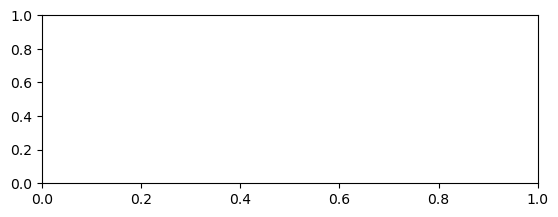

In [15]:
## 13
ax=plt.subplot(2,1,1)
plt.plot(f,gaussian_filter(rate_F1,sigma=0.1),label=r'$\lamda_{square}$')
plt.ylabel('Mean firing rate (sp/s)')
# plt.xlabel('F input')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.xlim((10,50))


ax=plt.subplot(2,1,2)
plt.plot(f,gaussian_filter(rate_F2,sigma=0.1),label=r'$\lambda_{constant}$')
# plt.ylabel('Mean firing rate (sp/s)')
plt.xlabel('Input frequency (Hz)')
plt.xlim((10,50))
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.legend()

### Simulations between two input frequencies


simulation time
7.858100175857544


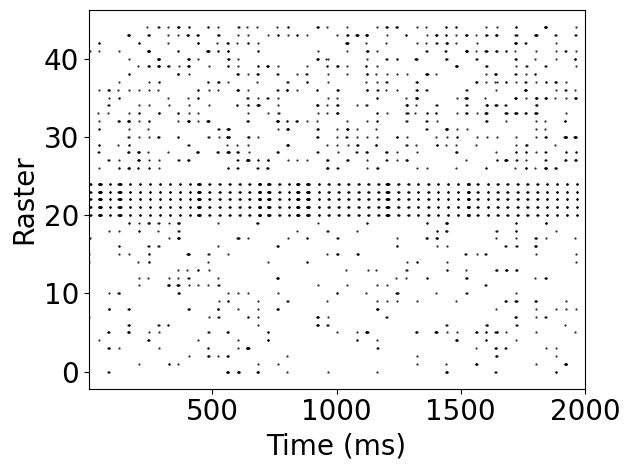

12.0
24.9


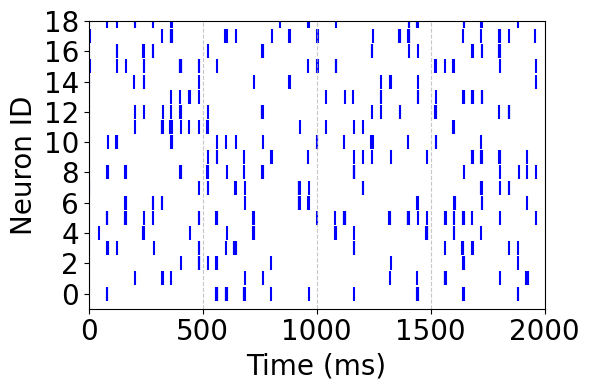

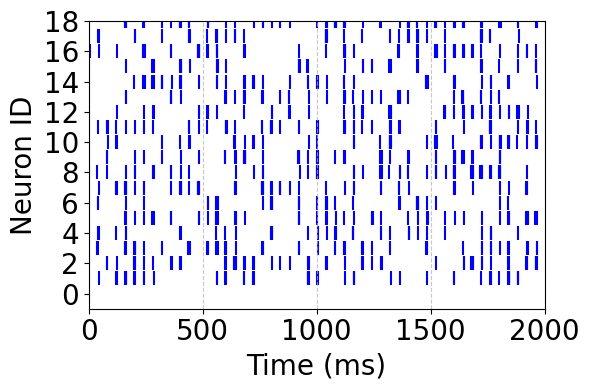

In [6]:
"""network: evaluate sync vs sync
"""
neuron_list = []
syn_list = []
Nneuron = 25
Nex = 20
A=20
v = np.empty((Nneuron+Nex, round(tf/dt)))  # Make sure it covers all indices
delay=1.5

F1 = 50
F2 = 25
r=1000
sizePulse=10

i=np.arange(0,round(tf/dt))-1
intervals=np.arange(0,tf/dt,1000/(F1*dt))
sig = pulse_train(
    t=i,              # time domain
    at=intervals,  # times of pulses
    shape=rect(sizePulse/dt)  # shape of pulse
)
sig = r*sig

intervals=np.arange(0,tf/dt,1000/(F2*dt))
sig2 = pulse_train(
    t=i,              # time domain
    at=intervals,  # times of pulses
    shape=rect(sizePulse/dt)  # shape of pulse
)
sig2 = r*sig2

for i in np.arange(0,Nneuron):
    if(i<Nex):
        neuron_list.append(PYR(i,Esyn=-5,tausyn=6,gsyn=4)) #EX cells, receives only from in
        syn_list.append(np.arange(Nex,Nneuron))
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
    else:
        neuron_list.append(PYR(i,gL=0.5,g1=0.0105,gsyn=4)) #IN cells, receives only from ex
        syn_list.append(np.concatenate((np.arange(0,Nex),np.arange(Nneuron,Nneuron+Nex))))
        neuron_list[-1].v = 0   
        
#second item
for i in np.arange(0,Nex):
        neuron_list.append(PYR(i,Esyn=-5,tausyn=6,gsyn=4)) #EX cells, receives only from in
        syn_list.append(np.arange(Nex,Nneuron))
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
  
start = time.time()    
for i in np.arange(0,round(tf/dt))-1:
    for n in np.arange(0,Nneuron+Nex):
        if(n<Nex and Ipoisson(sig[i])):
            neuron_list[n].add_external()
        if(n>Nneuron and Ipoisson(sig2[i])): #second item
            neuron_list[n].add_external()
        if(neuron_list[n].sendspk==1 and len(syn_list[n])>0): #checking if active synapse
            [ neuron_list[x].add_pre_spike(delay) for x in syn_list[n] ]
        neuron_list[n].eval(0,dt,i*dt)     
        v[n,i] = neuron_list[n].v
            
end = time.time() 
print('simulation time')
print(end - start)    

"""raster plot and other statistics"""

df = pd.DataFrame({'nid' : [], 'spktime' : []})
for n in np.arange(0,Nneuron+Nex):
    spks = neuron_list[n].spktimes
    df2 = pd.DataFrame({'nid' : n*np.ones(len(spks)), 'spktime' : spks})
    df = pd.concat([df, df2])
    
    
rate_F1 = len(df[df['nid']<Nex])/(tf*Nex*10**-3)  
rate_F2 = len(df[df['nid']>Nneuron])/(tf*Nex*10**-3)    

t = np.arange(0,tf,dt)    
# plt.figure(figsize=(10,10))
# plt.subplot(411)
# [x,y] = np.histogram(df[df['nid']<Nex]['spktime'],bins=1000) #only over PC
# plt.plot(y[1:],gaussian_filter(x,sigma=0.4))
# f1 = plt.figure(figsize=(8,10))
ax = plt.subplot(111)
plt.plot(df['spktime'],df['nid'],'.',c='k',ms=1)
plt.xlim([1,2000])
plt.ylabel('Raster')
plt.xlabel('Time (ms)')
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)

plt.tight_layout()
plt.savefig('F1_50_F2_25_new.png')
plt.show()
print(rate_F1)
print(rate_F2)

#####
pop1 = df[df['nid'] < Nex]
pop2 = df[(df['nid'] >= Nneuron) & (df['nid'] < Nneuron + Nex)]

# Plot Raster for Population 1
plt.figure(figsize=(6, 4))
ax=plt.subplot(111)
plt.scatter(pop1['spktime'], pop1['nid'], marker='|', color='blue', s=100)
# plt.title('Raster Plot - Excitatory Population 1', fontsize=16)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Neuron ID', fontsize=14)
plt.xlim([0, tf])
plt.ylim([-1, Nex-2])
plt.yticks(range(0, Nex, max(1, Nex // 10)))
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.tight_layout()
plt.savefig('Raster_Plot_Excitatory_Population1_noco_distractor.pdf')
plt.savefig('Raster_Plot_Excitatory_Population1_noco_distractor.png')
plt.show()

# Plot Raster for Population 2
plt.figure(figsize=(6, 4))
ax=plt.subplot(111)
# Adjust neuron IDs for plotting (e.g., 0 to Nex-1 for Population 2)
pop2_adjusted = pop2.copy()
pop2_adjusted['nid'] = pop2_adjusted['nid'] - Nneuron
plt.scatter(pop2_adjusted['spktime'], pop2_adjusted['nid'], marker='|', color='blue', s=100)
# plt.title('Raster Plot - Excitatory Population 2', fontsize=16)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Neuron ID', fontsize=14)
plt.xlim([0, tf])
plt.ylim([-1, Nex-2])
plt.yticks(range(0, Nex, max(1, Nex // 10)))
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.tight_layout()
plt.savefig('Raster_Plot_Excitatory_Population2_noco_target.pdf')
plt.savefig('Raster_Plot_Excitatory_Population2_noco_target.png')
plt.show()

Total neurons: 45, Total synapses: 45
Simulation time for input 0.5: 9.428152084350586
Total neurons: 45, Total synapses: 45
Simulation time for input 0.7777777777777778: 9.459836959838867
Total neurons: 45, Total synapses: 45
Simulation time for input 1.0555555555555556: 9.341351985931396
Total neurons: 45, Total synapses: 45
Simulation time for input 1.3333333333333335: 9.483708143234253
Total neurons: 45, Total synapses: 45
Simulation time for input 1.6111111111111112: 9.466048955917358
Total neurons: 45, Total synapses: 45
Simulation time for input 1.8888888888888888: 9.441620111465454
Total neurons: 45, Total synapses: 45
Simulation time for input 2.166666666666667: 9.491211175918579
Total neurons: 45, Total synapses: 45
Simulation time for input 2.4444444444444446: 9.48788595199585
Total neurons: 45, Total synapses: 45
Simulation time for input 2.7222222222222223: 9.460305213928223
Total neurons: 45, Total synapses: 45
Simulation time for input 3.0: 9.48892593383789


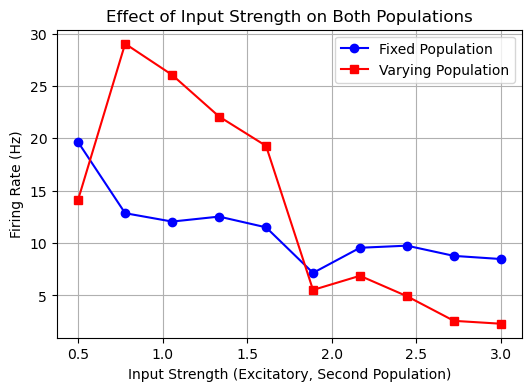

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Network parameters
Nneuron = 25
Nex = 20
delay = 1.5
tf = 2000  # Total simulation time in ms
dt = 0.1  # Time step

input_strengths = np.linspace(0.5, 3.0, 10)  # Varying input for the second population
firing_rates_pop1 = []
firing_rates_pop2 = []

for input_strength in input_strengths:
    neuron_list = []
    syn_list = []
    v = np.empty((Nneuron+Nex, round(tf/dt)))
    
    for i in range(Nneuron):
        if i < Nex:
            neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4))  # Fixed excitatory input
            syn_list.append(np.arange(Nex, Nneuron).tolist())
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10 
        else:
            neuron_list.append(PYR(i, gL=0.5, g1=0.0105, gsyn=4*input_strength))  # Keep inhibitory fixed
            syn_list.append(np.concatenate((np.arange(0, Nex), np.arange(Nneuron, Nneuron+Nex))).tolist())
            neuron_list[-1].v = 0   
    
    # Second item with varying input strength
    for i in range(Nex):
        neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4 * input_strength))
        syn_list.append(np.arange(Nex, Nneuron).tolist())
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
    
    print(f"Total neurons: {len(neuron_list)}, Total synapses: {len(syn_list)}")
    
    start = time.time()    
    for i in range(round(tf/dt) - 1):
        for n in range(len(neuron_list)):
            if n < Nex and Ipoisson(sig[i]):
                neuron_list[n].add_external()
            if n >= Nneuron and Ipoisson(sig2[i]):
                neuron_list[n].add_external()
            if n < len(syn_list) and neuron_list[n].sendspk == 1:
                valid_synapses = [x for x in syn_list[n] if x < len(neuron_list)]
                [neuron_list[x].add_pre_spike(delay) for x in valid_synapses]
            neuron_list[n].eval(0, dt, i * dt)     
            v[n, i] = neuron_list[n].v
    
    end = time.time() 
    print(f'Simulation time for input {input_strength}: {end - start}')    
    
    df = pd.DataFrame({'nid': [], 'spktime': []})
    for n in range(len(neuron_list)):
        spks = neuron_list[n].spktimes
        df2 = pd.DataFrame({'nid': n*np.ones(len(spks)), 'spktime': spks})
        df = pd.concat([df, df2])
    
    firing_rate_pop1 = len(df[df['nid'] < Nex]) / (tf * Nex * 10**-3)  # Fixed population
    firing_rate_pop2 = len(df[df['nid'] >= Nneuron]) / (tf * Nex * 10**-3)  # Varying population
    
    firing_rates_pop1.append(firing_rate_pop1)
    firing_rates_pop2.append(firing_rate_pop2)

plt.figure(figsize=(6, 4))
plt.plot(input_strengths, firing_rates_pop1, marker='o', linestyle='-', color='b', label='Fixed Population')
plt.plot(input_strengths, firing_rates_pop2, marker='s', linestyle='-', color='r', label='Varying Population')
plt.xlabel('Input Strength (Excitatory, Second Population)')
plt.ylabel('Firing Rate (Hz)')
plt.title('Effect of Input Strength on Both Populations')
plt.legend()
plt.grid(True)
plt.savefig('if_standard.pdf')
plt.savefig('if_standard.png')
plt.show()



Total neurons: 45, Total synapses: 45
Simulation time for input 0.5: 11.963201999664307
Total neurons: 45, Total synapses: 45
Simulation time for input 0.7777777777777778: 11.894135236740112
Total neurons: 45, Total synapses: 45
Simulation time for input 1.0555555555555556: 11.880671977996826
Total neurons: 45, Total synapses: 45
Simulation time for input 1.3333333333333335: 12.060113906860352
Total neurons: 45, Total synapses: 45
Simulation time for input 1.6111111111111112: 12.010488748550415
Total neurons: 45, Total synapses: 45
Simulation time for input 1.8888888888888888: 12.027469158172607
Total neurons: 45, Total synapses: 45
Simulation time for input 2.166666666666667: 12.037638902664185
Total neurons: 45, Total synapses: 45
Simulation time for input 2.4444444444444446: 12.074462175369263
Total neurons: 45, Total synapses: 45
Simulation time for input 2.7222222222222223: 12.15854525566101
Total neurons: 45, Total synapses: 45
Simulation time for input 3.0: 12.159181118011475


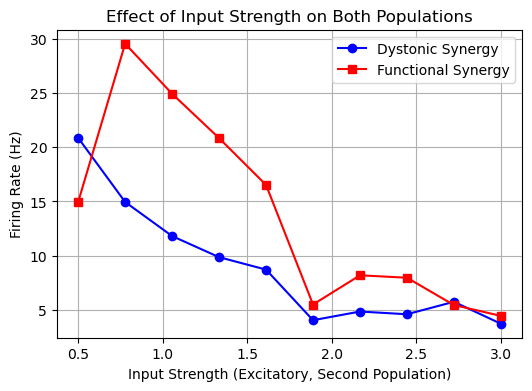

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Network parameters
Nneuron = 25
Nex = 20
delay = 1.5
tf = 2000  # Total simulation time in ms
dt = 0.1  # Time step

input_strengths = np.linspace(0.5, 3.0, 10)  # Varying input for the second population
firing_rates_pop1 = []
firing_rates_pop2 = []
firing_rates_inh = []

for input_strength in input_strengths:
    neuron_list = []
    syn_list = []
    v = np.empty((Nneuron+Nex, round(tf/dt)))
    
    for i in range(Nneuron):
        if i < Nex:
            neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4*input_strength))  # Fixed excitatory input
            syn_list.append(np.arange(Nex, Nneuron).tolist())
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10 
        else:
            neuron_list.append(PYR(i, gL=0.5, g1=0.0105, gsyn=4*input_strength))  # Keep inhibitory fixed
            syn_list.append(np.concatenate((np.arange(0, Nex), np.arange(Nneuron, Nneuron+Nex))).tolist())
            neuron_list[-1].v = 0   
    
    # Second item with varying input strength
    for i in range(Nex):
        neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4 * input_strength))
        syn_list.append(np.arange(Nex, Nneuron).tolist())
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
    
    print(f"Total neurons: {len(neuron_list)}, Total synapses: {len(syn_list)}")
    
    start = time.time()    
    for i in range(round(tf/dt) - 1):
        for n in range(len(neuron_list)):
            if n < Nex and Ipoisson(sig[i]):
                neuron_list[n].add_external()
            if n >= Nneuron and Ipoisson(sig2[i]):
                neuron_list[n].add_external()
            if n < len(syn_list) and neuron_list[n].sendspk == 1:
                valid_synapses = [x for x in syn_list[n] if x < len(neuron_list)]
                [neuron_list[x].add_pre_spike(delay) for x in valid_synapses]
            neuron_list[n].eval(0, dt, i * dt)     
            v[n, i] = neuron_list[n].v
    
    end = time.time() 
    print(f'Simulation time for input {input_strength}: {end - start}')    
    
    df = pd.DataFrame({'nid': [], 'spktime': []})
    for n in range(len(neuron_list)):
        spks = neuron_list[n].spktimes
        df2 = pd.DataFrame({'nid': n*np.ones(len(spks)), 'spktime': spks})
        df = pd.concat([df, df2])
    
    firing_rate_pop1 = len(df[df['nid'] < Nex]) / (tf * Nex * 10**-3)  # Fixed population
    firing_rate_pop2 = len(df[df['nid'] >= Nneuron]) / (tf * Nex * 10**-3)  # Varying population
    firing_rate_inh = len(df[(df['nid'] >= Nex) & (df['nid'] < Nneuron)]) / (tf * (Nneuron-Nex) * 10**-3)  # Inhibitory population
    
    firing_rates_pop1.append(firing_rate_pop1)
    firing_rates_pop2.append(firing_rate_pop2)  
    firing_rates_inh.append(firing_rate_inh)

plt.figure(figsize=(6, 4))
plt.plot(input_strengths, firing_rates_pop1, marker='o', linestyle='-', color='b', label='Dystonic Synergy')
plt.plot(input_strengths, firing_rates_pop2, marker='s', linestyle='-', color='r', label='Functional Synergy')
# plt.plot(input_strengths, firing_rates_inh, marker='s', linestyle='-', color='g', label='Inhibitory Population')
plt.xlabel('Input Strength (Excitatory, Second Population)')
plt.ylabel('Firing Rate (Hz)')
plt.title('Effect of Input Strength on Both Populations')
plt.legend()
plt.grid(True)
#plt.savefig('dis_emerge.pdf')
#plt.savefig('dis_emerge.png')
plt.show()



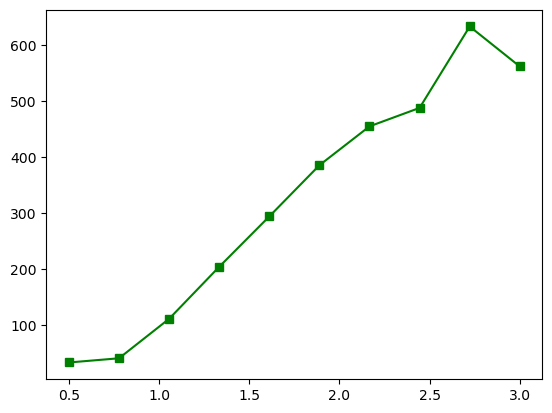

In [8]:
plt.plot(input_strengths, firing_rates_inh, marker='s', linestyle='-', color='g', label='Inhibitory Population')


Total neurons: 25, Total synapses: 25
Simulation time for input 0.5: 6.602588891983032
Total neurons: 25, Total synapses: 25
Simulation time for input 0.7777777777777778: 6.51466703414917
Total neurons: 25, Total synapses: 25
Simulation time for input 1.0555555555555556: 6.498063802719116
Total neurons: 25, Total synapses: 25
Simulation time for input 1.3333333333333335: 6.449259042739868
Total neurons: 25, Total synapses: 25
Simulation time for input 1.6111111111111112: 6.491930246353149
Total neurons: 25, Total synapses: 25
Simulation time for input 1.8888888888888888: 6.505245923995972
Total neurons: 25, Total synapses: 25
Simulation time for input 2.166666666666667: 6.524388074874878
Total neurons: 25, Total synapses: 25
Simulation time for input 2.4444444444444446: 6.7905309200286865
Total neurons: 25, Total synapses: 25
Simulation time for input 2.7222222222222223: 6.636123895645142
Total neurons: 25, Total synapses: 25
Simulation time for input 3.0: 6.957180976867676


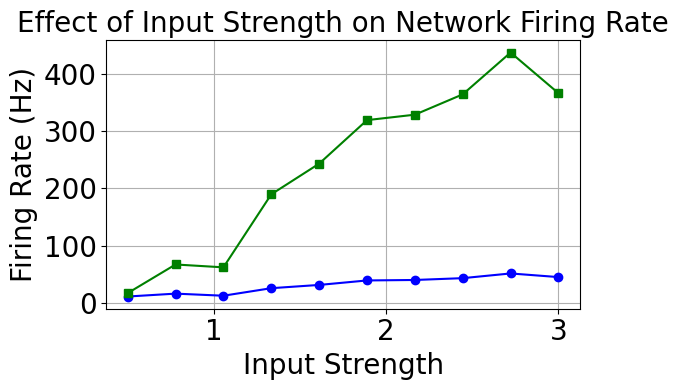

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Network parameters
Nneuron = 25
Nex = 20
delay = 1.5
tf = 2000  # Total simulation time in ms
dt = 0.1  # Time step

input_strengths = np.linspace(0.5, 3.0, 10)  # Varying input from 0.5 to 3.0
firing_rates = []
firing_rates_inh = []

for input_strength in input_strengths:
    neuron_list = []
    syn_list = []
    v = np.empty((Nneuron+Nex, round(tf/dt)))
    
    for i in range(Nneuron):
        if i < Nex:
            neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4 * input_strength))
            syn_list.append(np.arange(Nex, Nneuron).tolist())
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10 
        else:
            neuron_list.append(PYR(i, gL=0.5, g1=0.0105, gsyn=3 * input_strength))
            syn_list.append(np.concatenate((np.arange(0, Nex), np.arange(Nneuron, Nneuron+Nex))).tolist())
            neuron_list[-1].v = 0   
    
    print(f"Total neurons: {len(neuron_list)}, Total synapses: {len(syn_list)}")
    
    start = time.time()    
    for i in range(round(tf/dt) - 1):
        for n in range(len(neuron_list)):
            if n < Nex and Ipoisson(sig[i]):
                neuron_list[n].add_external()
            if n >= Nneuron and Ipoisson(sig2[i]):
                neuron_list[n].add_external()
            if n < len(syn_list) and neuron_list[n].sendspk == 1:
                valid_synapses = [x for x in syn_list[n] if x < len(neuron_list)]
                [neuron_list[x].add_pre_spike(delay) for x in valid_synapses]
            neuron_list[n].eval(0, dt, i * dt)     
            v[n, i] = neuron_list[n].v
    
    end = time.time() 
    print(f'Simulation time for input {input_strength}: {end - start}')    
    
    df = pd.DataFrame({'nid': [], 'spktime': []})
    for n in range(len(neuron_list)):
        spks = neuron_list[n].spktimes
        df2 = pd.DataFrame({'nid': n*np.ones(len(spks)), 'spktime': spks})
        df = pd.concat([df, df2])
        
    firing_rate_inh = len(df[(df['nid'] >= Nex) & (df['nid'] < Nneuron)]) / (tf * (Nneuron-Nex) * 10**-3)  # Inhibitory population
    firing_rate = len(df) / (tf * (Nneuron + Nex) * 10**-3)
    firing_rates.append(firing_rate)
    firing_rates_inh.append(firing_rate_inh)

plt.figure(figsize=(6, 4))
ax=plt.subplot(111)
plt.plot(input_strengths, firing_rates, marker='o', linestyle='-', color='b')
plt.plot(input_strengths, firing_rates_inh, marker='s', linestyle='-', color='g', label='Inhibitory Population')
plt.xlabel('Input Strength')
plt.ylabel('Firing Rate (Hz)')
plt.title('Effect of Input Strength on Network Firing Rate')
plt.grid(True)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.tight_layout()
# plt.savefig('if_1pop.pdf')
# plt.savefig('if_1pop.png')
plt.show()



/Users/rodrigo/anaconda3/envs/mlenv/lib/python3.7/site-packages/ipykernel_launcher.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  # This is added back by InteractiveShellApp.init_path()


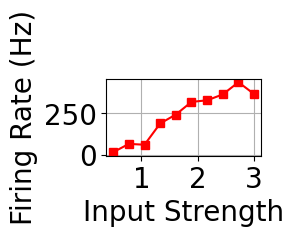

In [13]:
plt.figure(figsize=(2, 1))
ax=plt.subplot(111)
plt.plot(input_strengths, firing_rates_inh, marker='s', linestyle='-', color='r', label='Inhibitory Population')
plt.xlabel('Input Strength')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.tight_layout()
plt.savefig('if_inh.pdf')
plt.savefig('if_inh.png')
plt.show()

Total neurons: 45, Total synapses: 45
Simulation time for input 0.5: 9.640161752700806
Total neurons: 45, Total synapses: 45
Simulation time for input 0.7777777777777778: 9.545111179351807
Total neurons: 45, Total synapses: 45
Simulation time for input 1.0555555555555556: 9.585251808166504
Total neurons: 45, Total synapses: 45
Simulation time for input 1.3333333333333335: 9.446048974990845
Total neurons: 45, Total synapses: 45
Simulation time for input 1.6111111111111112: 9.690899848937988
Total neurons: 45, Total synapses: 45
Simulation time for input 1.8888888888888888: 9.686994075775146
Total neurons: 45, Total synapses: 45
Simulation time for input 2.166666666666667: 9.501776218414307
Total neurons: 45, Total synapses: 45
Simulation time for input 2.4444444444444446: 9.413633108139038
Total neurons: 45, Total synapses: 45
Simulation time for input 2.7222222222222223: 9.454896211624146
Total neurons: 45, Total synapses: 45
Simulation time for input 3.0: 9.73253083229065


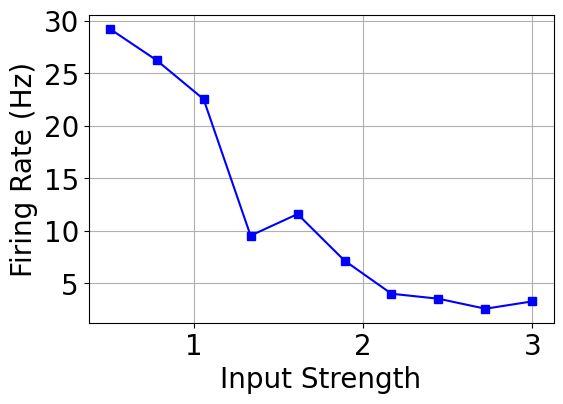

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Network parameters
Nneuron = 25
Nex = 20
delay = 1.5
tf = 2000  # Total simulation time in ms
dt = 0.1  # Time step

input_strengths = np.linspace(0.5, 3.0, 10)  # Varying input for the second population
firing_rates_pop1 = []
firing_rates_pop2 = []

for input_strength in input_strengths:
    neuron_list = []
    syn_list = []
    v = np.empty((Nneuron+Nex, round(tf/dt)))
    
    for i in range(Nneuron):
        if i < Nex:
            neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4))  # Fixed excitatory input
            syn_list.append(np.arange(Nex, Nneuron).tolist())
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10 
        else:
            neuron_list.append(PYR(i, gL=0.5, g1=0.0105, gsyn=6* input_strength))  # Keep inhibitory fixed
            syn_list.append(np.concatenate((np.arange(0, Nex), np.arange(Nneuron, Nneuron+Nex))).tolist())
            neuron_list[-1].v = 0   
    
    # Second item with varying input strength
    for i in range(Nex):
        neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4 * input_strength))
        syn_list.append(np.arange(Nex, Nneuron).tolist())
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
    
    print(f"Total neurons: {len(neuron_list)}, Total synapses: {len(syn_list)}")
    
    start = time.time()    
    for i in range(round(tf/dt) - 1):
        for n in range(len(neuron_list)):
            if n < Nex and Ipoisson(sig[i]):
                neuron_list[n].add_external()
            if n >= Nneuron and Ipoisson(sig2[i]):
                neuron_list[n].add_external()
            if n < len(syn_list) and neuron_list[n].sendspk == 1:
                valid_synapses = [x for x in syn_list[n] if x < len(neuron_list)]
                [neuron_list[x].add_pre_spike(delay) for x in valid_synapses]
            neuron_list[n].eval(0, dt, i * dt)     
            v[n, i] = neuron_list[n].v
    
    end = time.time() 
    print(f'Simulation time for input {input_strength}: {end - start}')    
    
    df = pd.DataFrame({'nid': [], 'spktime': []})
    for n in range(len(neuron_list)):
        spks = neuron_list[n].spktimes
        df2 = pd.DataFrame({'nid': n*np.ones(len(spks)), 'spktime': spks})
        df = pd.concat([df, df2])
    
    firing_rate_pop1 = len(df[df['nid'] < Nex]) / (tf * Nex * 10**-3)  # Fixed population
    firing_rate_pop2 = len(df[df['nid'] >= Nneuron]) / (tf * Nex * 10**-3)  # Varying population
    
    firing_rates_pop1.append(firing_rate_pop1)
    firing_rates_pop2.append(firing_rate_pop2)

plt.figure(figsize=(6, 4))
ax=plt.subplot(111)
# plt.plot(input_strengths, firing_rates_pop1, marker='o', linestyle='-', color='b', label='Dystonic Synergy')
plt.plot(input_strengths, firing_rates_pop2, marker='s', linestyle='-', color='b', label='Functional Synergy')
plt.xlabel('Input Strength')
plt.ylabel('Firing Rate (Hz)')
# plt.title('Effect of Input Strength on Both Populations')
# plt.legend()
plt.grid(True)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.savefig('unbalance.pdf')
plt.savefig('unbalance.png')
plt.show()



Total neurons: 45, Total synapses: 45
Simulation time for input 0.5: 9.671266078948975
Total neurons: 45, Total synapses: 45
Simulation time for input 0.7777777777777778: 9.688251972198486
Total neurons: 45, Total synapses: 45
Simulation time for input 1.0555555555555556: 9.766317129135132
Total neurons: 45, Total synapses: 45
Simulation time for input 1.3333333333333335: 9.80741286277771
Total neurons: 45, Total synapses: 45
Simulation time for input 1.6111111111111112: 9.855254650115967
Total neurons: 45, Total synapses: 45
Simulation time for input 1.8888888888888888: 9.793802976608276
Total neurons: 45, Total synapses: 45
Simulation time for input 2.166666666666667: 9.903964042663574
Total neurons: 45, Total synapses: 45
Simulation time for input 2.4444444444444446: 9.815700054168701
Total neurons: 45, Total synapses: 45
Simulation time for input 2.7222222222222223: 9.848102807998657
Total neurons: 45, Total synapses: 45
Simulation time for input 3.0: 9.820385932922363


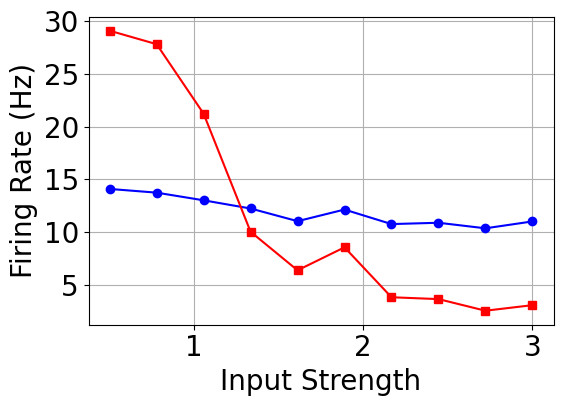

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Network parameters
Nneuron = 25
Nex = 20
delay = 1.5
tf = 2000  # Total simulation time in ms
dt = 0.1  # Time step

input_strengths = np.linspace(0.5, 3.0, 10)  # Varying input for the second population
firing_rates_pop1 = []
firing_rates_pop2 = []

for input_strength in input_strengths:
    neuron_list = []
    syn_list = []
    v = np.empty((Nneuron+Nex, round(tf/dt)))
    
    for i in range(Nneuron):
        if i < Nex:
            neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=2))  # Fixed excitatory input
            syn_list.append(np.arange(Nex, Nneuron).tolist())
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10 
        else:
            neuron_list.append(PYR(i, gL=0.5, g1=0.0105, gsyn=6* input_strength))  # Keep inhibitory fixed
            syn_list.append(np.concatenate((np.arange(0, Nex), np.arange(Nneuron, Nneuron+Nex))).tolist())
            neuron_list[-1].v = 0   
    
    # Second item with varying input strength
    for i in range(Nex):
        neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4 * input_strength))
        syn_list.append(np.arange(Nex, Nneuron).tolist())
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
    
    print(f"Total neurons: {len(neuron_list)}, Total synapses: {len(syn_list)}")
    
    start = time.time()    
    for i in range(round(tf/dt) - 1):
        for n in range(len(neuron_list)):
            if n < Nex and Ipoisson(sig[i]):
                neuron_list[n].add_external()
            if n >= Nneuron and Ipoisson(sig2[i]):
                neuron_list[n].add_external()
            if n < len(syn_list) and neuron_list[n].sendspk == 1:
                valid_synapses = [x for x in syn_list[n] if x < len(neuron_list)]
                [neuron_list[x].add_pre_spike(delay) for x in valid_synapses]
            neuron_list[n].eval(0, dt, i * dt)     
            v[n, i] = neuron_list[n].v
    
    end = time.time() 
    print(f'Simulation time for input {input_strength}: {end - start}')    
    
    df = pd.DataFrame({'nid': [], 'spktime': []})
    for n in range(len(neuron_list)):
        spks = neuron_list[n].spktimes
        df2 = pd.DataFrame({'nid': n*np.ones(len(spks)), 'spktime': spks})
        df = pd.concat([df, df2])
    
    firing_rate_pop1 = len(df[df['nid'] < Nex]) / (tf * Nex * 10**-3)  # Fixed population
    firing_rate_pop2 = len(df[df['nid'] >= Nneuron]) / (tf * Nex * 10**-3)  # Varying population
    
    firing_rates_pop1.append(firing_rate_pop1)
    firing_rates_pop2.append(firing_rate_pop2)

plt.figure(figsize=(6, 4))
ax=plt.subplot(111)
plt.plot(input_strengths, firing_rates_pop1, marker='o', linestyle='-', color='b', label='Dystonic Synergy')
plt.plot(input_strengths, firing_rates_pop2, marker='s', linestyle='-', color='r', label='Functional Synergy')
plt.xlabel('Input Strength')
plt.ylabel('Firing Rate (Hz)')
# plt.title('Effect of Input Strength on Both Populations')
plt.legend()
plt.grid(True)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
plt.savefig('further_unbalance.pdf')
plt.savefig('further_unbalance.png')
plt.show()


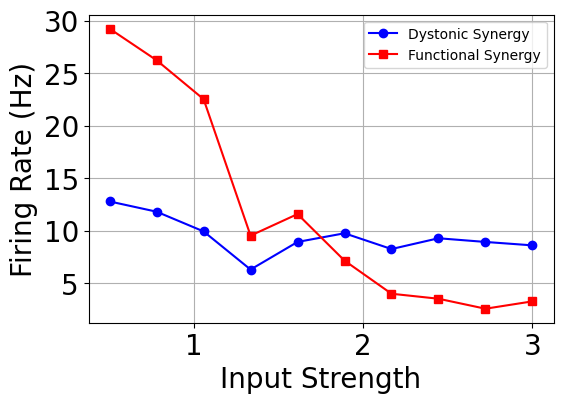

In [28]:
plt.figure(figsize=(6, 4))
ax=plt.subplot(111)
plt.plot(input_strengths, firing_rates_pop1, marker='o', linestyle='-', color='b', label='Dystonic Synergy')
plt.plot(input_strengths, firing_rates_pop2, marker='s', linestyle='-', color='r', label='Functional Synergy')
plt.xlabel('Input Strength')
plt.ylabel('Firing Rate (Hz)')
# plt.title('Effect of Input Strength on Both Populations')
plt.legend()
plt.grid(True)
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
# plt.savefig('further_unbalance.pdf')
# plt.savefig('further_unbalance.png')
plt.show()

simulation time
9.86507511138916


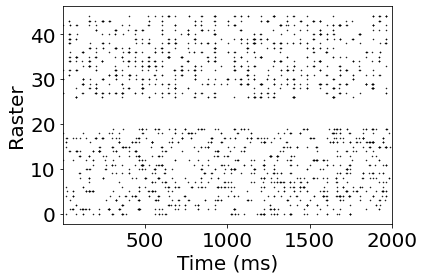

27.75
25.525


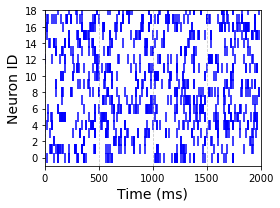

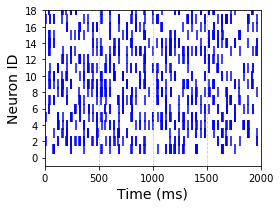

In [18]:
"""network: evaluate sync vs sync inh disrupted
"""
neuron_list = []
syn_list = []
Nneuron = 25
Nex = 20
A=20
v = np.empty((Nneuron+Nex, round(tf/dt)))  # Make sure it covers all indices
delay=1.5

F1 = 50
F2 = 25
r=1000
sizePulse=10

i=np.arange(0,round(tf/dt))-1
intervals=np.arange(0,tf/dt,1000/(F1*dt))
sig = pulse_train(
    t=i,              # time domain
    at=intervals,  # times of pulses
    shape=rect(sizePulse/dt)  # shape of pulse
)
sig = r*sig

intervals=np.arange(0,tf/dt,1000/(F2*dt))
sig2 = pulse_train(
    t=i,              # time domain
    at=intervals,  # times of pulses
    shape=rect(sizePulse/dt)  # shape of pulse
)
sig2 = r*sig2

for i in np.arange(0,Nneuron):
    if(i<Nex):
        neuron_list.append(PYR(i,Esyn=-5,tausyn=6,gsyn=4)) #EX cells, receives only from in
        syn_list.append(np.arange(Nex,Nneuron))
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
    else:
        neuron_list.append(PYR(i,gL=0.5,g1=0.0105,gsyn=1)) #IN cells, receives only from ex  #gsyn=3
        syn_list.append(np.concatenate((np.arange(0,Nex),np.arange(Nneuron,Nneuron+Nex))))
        neuron_list[-1].v = 0   
        
#second item
for i in np.arange(0,Nex):
        neuron_list.append(PYR(i,Esyn=-5,tausyn=6,gsyn=4)) #EX cells, receives only from in
        syn_list.append(np.arange(Nex,Nneuron))
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
  
start = time.time()    
for i in np.arange(0,round(tf/dt))-1:
    for n in np.arange(0,Nneuron+Nex):
        if(n<Nex and Ipoisson(sig[i])):
            neuron_list[n].add_external()
        if(n>Nneuron and Ipoisson(sig2[i])): #second item
            neuron_list[n].add_external()
        if(neuron_list[n].sendspk==1 and len(syn_list[n])>0): #checking if active synapse
            [ neuron_list[x].add_pre_spike(delay) for x in syn_list[n] ]
        neuron_list[n].eval(0,dt,i*dt)     
        v[n,i] = neuron_list[n].v
            
end = time.time() 
print('simulation time')
print(end - start)    

"""raster plot and other statistics"""

df = pd.DataFrame({'nid' : [], 'spktime' : []})
for n in np.arange(0,Nneuron+Nex):
    spks = neuron_list[n].spktimes
    df2 = pd.DataFrame({'nid' : n*np.ones(len(spks)), 'spktime' : spks})
    df = pd.concat([df, df2])
    
    
rate_F1 = len(df[df['nid']<Nex])/(tf*Nex*10**-3)  
rate_F2 = len(df[df['nid']>Nneuron])/(tf*Nex*10**-3)    

t = np.arange(0,tf,dt)    
# plt.figure(figsize=(10,10))
# plt.subplot(411)
# [x,y] = np.histogram(df[df['nid']<Nex]['spktime'],bins=1000) #only over PC
# plt.plot(y[1:],gaussian_filter(x,sigma=0.4))
# f1 = plt.figure(figsize=(8,10))
ax = plt.subplot(111)
plt.plot(df['spktime'],df['nid'],'.',c='k',ms=1)
plt.xlim([1,2000])
plt.ylabel('Raster')
plt.xlabel('Time (ms)')
plt.locator_params(axis='x', nbins=4)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)

plt.tight_layout()
plt.savefig('F1_50_F2_25_new.png')
plt.show()
print(rate_F1)
print(rate_F2)

#####
pop1 = df[df['nid'] < Nex]
pop2 = df[(df['nid'] >= Nneuron) & (df['nid'] < Nneuron + Nex)]

# Plot Raster for Population 1
plt.figure(figsize=(4, 3))
plt.scatter(pop1['spktime'], pop1['nid'], marker='|', color='blue', s=100)
# plt.title('Raster Plot - Excitatory Population 1', fontsize=16)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Neuron ID', fontsize=14)
plt.xlim([0, tf])
plt.ylim([-1, Nex-2])
plt.yticks(range(0, Nex, max(1, Nex // 10)))
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Raster_Plot_Excitatory_Population1_noco_distractor_balance.pdf')
plt.savefig('Raster_Plot_Excitatory_Population1_noco_distractor_balance.png')
plt.show()

# Plot Raster for Population 2
plt.figure(figsize=(4, 3))
# Adjust neuron IDs for plotting (e.g., 0 to Nex-1 for Population 2)
pop2_adjusted = pop2.copy()
pop2_adjusted['nid'] = pop2_adjusted['nid'] - Nneuron
plt.scatter(pop2_adjusted['spktime'], pop2_adjusted['nid'], marker='|', color='blue', s=100)
# plt.title('Raster Plot - Excitatory Population 2', fontsize=16)
plt.xlabel('Time (ms)', fontsize=14)
plt.ylabel('Neuron ID', fontsize=14)
plt.xlim([0, tf])
plt.ylim([-1, Nex-2])
plt.yticks(range(0, Nex, max(1, Nex // 10)))
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Raster_Plot_Excitatory_Population2_noco_target_balance.pdf')
plt.savefig('Raster_Plot_Excitatory_Population2_noco_target_balance.png')
plt.show()

Total neurons: 45, Total synapses: 45
Simulation time for input 0.5: 9.504157066345215
Total neurons: 45, Total synapses: 45
Simulation time for input 0.7777777777777778: 9.418243169784546
Total neurons: 45, Total synapses: 45
Simulation time for input 1.0555555555555556: 9.423181056976318
Total neurons: 45, Total synapses: 45
Simulation time for input 1.3333333333333335: 9.317409038543701
Total neurons: 45, Total synapses: 45
Simulation time for input 1.6111111111111112: 9.409514904022217
Total neurons: 45, Total synapses: 45
Simulation time for input 1.8888888888888888: 9.477260112762451
Total neurons: 45, Total synapses: 45
Simulation time for input 2.166666666666667: 9.486983299255371
Total neurons: 45, Total synapses: 45
Simulation time for input 2.4444444444444446: 9.45011591911316
Total neurons: 45, Total synapses: 45
Simulation time for input 2.7222222222222223: 9.499000072479248
Total neurons: 45, Total synapses: 45
Simulation time for input 3.0: 9.454808950424194


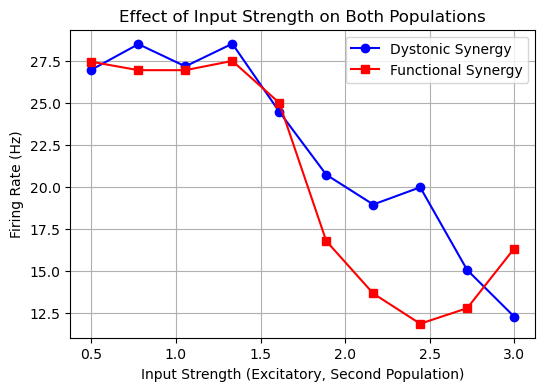

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Network parameters
Nneuron = 25
Nex = 20
delay = 1.5
tf = 2000  # Total simulation time in ms
dt = 0.1  # Time step

input_strengths = np.linspace(0.5, 3.0, 10)  # Varying input for the second population
firing_rates_pop1 = []
firing_rates_pop2 = []

for input_strength in input_strengths:
    neuron_list = []
    syn_list = []
    v = np.empty((Nneuron+Nex, round(tf/dt)))
    
    for i in range(Nneuron):
        if i < Nex:
            neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4))  # Fixed excitatory input
            syn_list.append(np.arange(Nex, Nneuron).tolist())
            neuron_list[-1].v = 0
            neuron_list[-1].tau1 = 10 
        else:
            neuron_list.append(PYR(i, gL=0.5, g1=0.0105, gsyn=1* input_strength))  # Keep inhibitory fixed
            syn_list.append(np.concatenate((np.arange(0, Nex), np.arange(Nneuron, Nneuron+Nex))).tolist())
            neuron_list[-1].v = 0   
    
    # Second item with varying input strength
    for i in range(Nex):
        neuron_list.append(PYR(i, Esyn=-5, tausyn=6, gsyn=4 * input_strength))
        syn_list.append(np.arange(Nex, Nneuron).tolist())
        neuron_list[-1].v = 0
        neuron_list[-1].tau1 = 10 
    
    print(f"Total neurons: {len(neuron_list)}, Total synapses: {len(syn_list)}")
    
    start = time.time()    
    for i in range(round(tf/dt) - 1):
        for n in range(len(neuron_list)):
            if n < Nex and Ipoisson(sig[i]):
                neuron_list[n].add_external()
            if n >= Nneuron and Ipoisson(sig2[i]):
                neuron_list[n].add_external()
            if n < len(syn_list) and neuron_list[n].sendspk == 1:
                valid_synapses = [x for x in syn_list[n] if x < len(neuron_list)]
                [neuron_list[x].add_pre_spike(delay) for x in valid_synapses]
            neuron_list[n].eval(0, dt, i * dt)     
            v[n, i] = neuron_list[n].v
    
    end = time.time() 
    print(f'Simulation time for input {input_strength}: {end - start}')    
    
    df = pd.DataFrame({'nid': [], 'spktime': []})
    for n in range(len(neuron_list)):
        spks = neuron_list[n].spktimes
        df2 = pd.DataFrame({'nid': n*np.ones(len(spks)), 'spktime': spks})
        df = pd.concat([df, df2])
    
    firing_rate_pop1 = len(df[df['nid'] < Nex]) / (tf * Nex * 10**-3)  # Fixed population
    firing_rate_pop2 = len(df[df['nid'] >= Nneuron]) / (tf * Nex * 10**-3)  # Varying population
    
    firing_rates_pop1.append(firing_rate_pop1)
    firing_rates_pop2.append(firing_rate_pop2)

plt.figure(figsize=(6, 4))
plt.plot(input_strengths, firing_rates_pop1, marker='o', linestyle='-', color='b', label='Dystonic Synergy')
plt.plot(input_strengths, firing_rates_pop2, marker='s', linestyle='-', color='r', label='Functional Synergy')
plt.xlabel('Input Strength (Excitatory, Second Population)')
plt.ylabel('Firing Rate (Hz)')
plt.title('Effect of Input Strength on Both Populations')
plt.legend()
plt.grid(True)
plt.savefig('if_unbalanced.pdf')
plt.savefig('if_unbalanced.png')
plt.show()
